In [262]:
import numpy as np
import matplotlib.pyplot as plt
t=np.arange(0,20+.0001,.0001)
analytical=300-300*np.exp(-1000*t)+50*np.sin(.01*t)-.0005*np.cos(.01*t)+np.exp(-1000*t)*(.0005+T0)

In [263]:
# --- Global Parameters ---
h_val = 1000
T0 = 500
t0 = 0
tf = 20

def T_ambient(t):
    return 300 + 50 * np.sin(0.01 * t)

def f(t, T):
    return -h_val * (T - T_ambient(t))

def f_prime(T):
    return -h_val

# --- Damped Newton-Raphson Solver ---
def damped_nr_step(f, y_prev, t_next, h, tol=1e-6, max_iter=50):
    y_curr = y_prev # Initial guess
    nr_count=0
    for i in range(max_iter):
        nr_count=nr_count+1
        # Calculate the residual g(y)
        g_val = y_curr - y_prev - h * f(t_next, y_curr)
        dg_val = 1 - h * f_prime(y_curr)
        
        # Calculate the full Newton step
        delta = -g_val / dg_val
        
        # Line search for damping factor alpha
        alpha = 1.0
        while abs(y_curr + alpha * delta - y_prev - h *
                  f(t_next, y_curr + alpha * delta)) >= abs(g_val):
            alpha = alpha / 2.0
            if alpha < 1e-4:
                break
        
        # Update with damped step
        y_new = y_curr + alpha * delta
        
        if abs(y_new - y_curr) < tol:
            return y_new, i + 1
        y_curr = y_new
        
    return y_curr, nr_count

# --- Adaptive Implicit Euler ---
def adaptive_implicit_euler(f, y0, t0, t_final, h0, tol):
    # Initialize lists to store our results
    t_list = [t0]
    y_list = [y0]
    h_list = [h0] # To keep track of step sizes used
    error_list=[]
    error_t=[]
    t_adapt = []
    y_adapt = []
    accepted_list = [0]
    rejected_list= [0]
    
    # Starting values
    t_current = t0
    y_current = y0
    h = h0
    
    # Counters for stats
    accepted_count = 0
    rejected_count = 0
    total_nr=0
    while t_current < t_final:
        # need the time at the end of the step
        t_next = t_current + h
        y_full, nr_count = damped_nr_step(f, y_current, t_next, h)
        total_nr=total_nr+nr_count
        h_half = h / 2.0
        # First half-step to the middle
        t_mid = t_current + h_half
        y_mid,nr_count = damped_nr_step(f, y_current, t_mid, h_half)
        total_nr=total_nr+nr_count
        # Second half-step to the end
        y_half,nr_count = damped_nr_step(f, y_mid, t_next, h_half)
        total_nr=total_nr+nr_count
        
        # absolute difference between the two methods
        error_est = abs(y_half - y_full)
        error_list.append(error_est)
        error_t.append(t_current)
        if error_est < tol:
            # ACCEPT
            t_current = t_current + h
            y_current = y_half
            
            t_list.append(t_current)
            y_list.append(y_current)
            h_list.append(h)
            
            accepted_count = accepted_count + 1
            accepted_list.append(accepted_count)
            rejected_list.append(rejected_count)
            
            # try to make h bigger
            h_new = h * np.sqrt(tol / (error_est + 1e-10))
            h = 0.9 * h_new
        else:
            # REJECT
            rejected_count = rejected_count + 1
            h_new = h * np.sqrt(tol / (error_est + 1e-10))
            h = .99*h_new
            t_adapt.append(t_current)
            y_adapt.append(y_current)
        # h doesn't get too small or too big
        if h > 5.0:
            h = 5.0
        else:
            t_adapt.append(t_current)
            y_adapt.append(y_current)
        if h < 1e-6:
            h = 1e-6
            t_current = t_current + h
            y_current = y_half
            
            t_list.append(t_current)
            y_list.append(y_current)
            h_list.append(h)
            accepted_list.append(accepted_count)
            rejected_list.append(rejected_count)
        # don't go past the final time
        if t_current + h > t_final:
            h = t_final - t_current
    return np.array(t_list), np.array(y_list), h_list, accepted_count, rejected_count, total_nr,t_adapt,y_adapt,error_list,error_t,accepted_list,rejected_list
def backward_euler_damped1(f, y0, t0, t_final, h):
    t_values = np.arange(t0, tf + h, h)
    y_values = np.zeros_like(t_values)
    y_values[0] = y0
    iterations_log = []
    backtrack_log = []
    alpha_log = []
    damping_used_log = []
    error_max=0
    for i in range(1, len(t_values)):
        t_next = t_values[i]
        y_prev = y_values[i-1]
        result, nr_count=damped_nr_step(f, y_prev, t_next, h, tol=1e-6, max_iter=50)
        y_values[i] = result
        iterations_log.append(nr_count)
        #Estimate Error (in order to compare to adaptive)
        h_half = h / 2.0
        # First half-step to the middle
        t_mid = t_values[i-1] + h_half
        y_mid,nr_count = damped_nr_step(f, y_prev, t_mid, h_half)
        # Second half-step to the end
        y_half,nr_count = damped_nr_step(f, y_mid, t_next, h_half)
        error_est = abs(y_half - result)
        if error_est>=error_max:
            error_max=error_est
    return t_values, y_values, iterations_log, backtrack_log, alpha_log,damping_used_log,error_max


## Performance Analysis

#### Fixed Solve 

In [264]:
#Same Step Budget
T0=500
t0=0
t_final=20
t_damped, T_damped, iters, backs, alphas, damp_used,e = \
backward_euler_damped1(f, T0, t0, t_final, .00934)
print("Maximum Error",e)
print("Number of Steps:",np.sum(iters))

Maximum Error 13.121339906837704
Number of Steps: 4284


In [265]:
#Same Accuracy Target (.412)
T0=500
t0=0
t_final=20
t_damped1, T_damped1, iters1, backs1, alphas1, damp_used1,error_max = \
backward_euler_damped1(f, T0, t0, t_final, .0001)
print("Maximum Error",error_max)
print("Number of Steps",np.sum(iters1))

Maximum Error 0.41228715728715315
Number of Steps 400000


#### Adaptive Solve

In [268]:
#Same Step Budget
T0 = 500.0
t_start, t_end = 0, 20
tol_target = 5e-4
t_vals, T_vals, h_vals, accepted_count, rejected_count, total_nr,t_adapt, y_adapt,error_list,error_t,accepted_list,rejected_list \
     = adaptive_implicit_euler(f, T0, t_start, t_end, .5, tol_target)
print("Number of Steps:",total_nr)
print("Maximum Error:",tol_target)

Number of Steps: 4284
Maximum Error: 0.0005


In [269]:
#Same Accuracy Target (.412)
T0 = 500.0
t_start, t_end = 0, 20
tol_target = 4.12e-1
t_vals1, T_vals1, h_vals1, accepted_count1, rejected_count1, total_nr1,t_adapt1, y_adapt1,error_list1,error_t1,accepted_list1,rejected_list1 \
     = adaptive_implicit_euler(f, T0, t_start, t_end, .1, tol_target)
print("Maximum Error:",tol_target)
print("Number of Steps:",total_nr1)

Maximum Error: 0.412
Number of Steps: 228


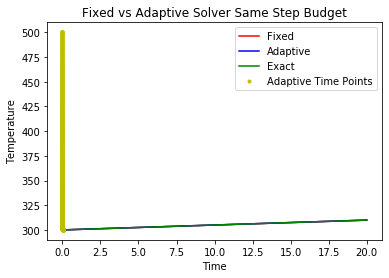

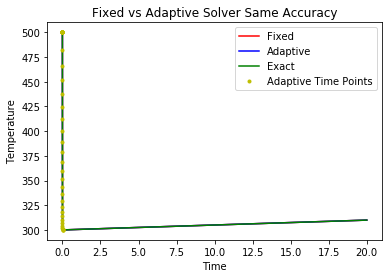

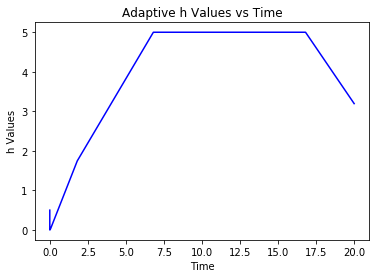

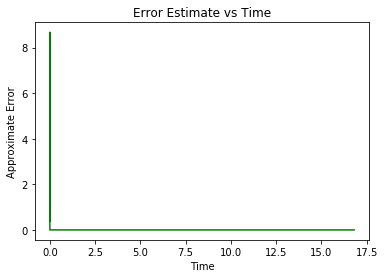

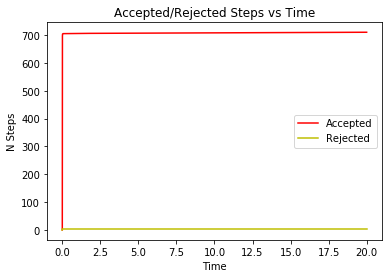

In [270]:
#Plot same step budget
plt.figure()
plt.plot(t_damped,T_damped, 'r-',label="Fixed")
plt.plot(t_vals,T_vals,'b-',label="Adaptive")
plt.plot(t, analytical, 'g-',label="Exact")
plt.plot(t_adapt,y_adapt,'y.',label="Adaptive Time Points")
plt.legend()
plt.title("Fixed vs Adaptive Solver Same Step Budget")
plt.xlabel("Time")
plt.ylabel("Temperature")
plt.show()

#Plot same accuracy target
plt.title("Fixed vs Adaptive Solver Same Accuracy")
plt.xlabel("Time")
plt.ylabel("Temperature")
plt.plot(t_damped1,T_damped1, 'r-',label="Fixed")
plt.plot(t_vals1,T_vals1,'b-',label="Adaptive")
plt.plot(t, analytical, 'g-',label="Exact")
plt.plot(t_adapt1,y_adapt1,'y.',label="Adaptive Time Points")
plt.legend()
plt.show()

#Plot adaptive h values vs time
plt.plot(t_vals,h_vals,'b-')
plt.title("Adaptive h Values vs Time")
plt.xlabel("Time")
plt.ylabel("h Values")
plt.show()

#Plot error estimate
plt.plot(error_t,error_list,'g-')
plt.title("Error Estimate vs Time")
plt.xlabel("Time")
plt.ylabel("Approximate Error")
plt.show()

#Plot accepted and rejected steps
plt.plot(t_vals,accepted_list,'r-',label="Accepted")
plt.plot(t_vals,rejected_list,'y-',label="Rejected")
plt.title("Accepted/Rejected Steps vs Time")
plt.xlabel("Time")
plt.ylabel("N Steps")
plt.legend()
plt.show()

### Section 4: Performance Analysis

As is evident based on the investigation above, the adaptive solver has several clear advantages over the fixed solver. First, when tested with the same target accuracy, the adaptive solver achieved the target with .00057 times the steps that the fixed solver took. In addition, when given the same step size budget the adaptive solver was able to achieve 26,240 times the accuracy. This demonstrates why adaptive solvers are superior to fixed solvers for complex systems like stiff equations.

## Robustness Test

In [280]:
#Large Starting h
T0 = 500.0
t_start, t_end = 0, 20
tol_target = 1e-3
t_vals, T_vals, h_vals, accepted_count, rejected_count, total_nr,t_adapt, y_adapt,error_list,error_t,accepted_list,rejected_list \
     = adaptive_implicit_euler(f, T0, t_start, t_end, 5, tol_target)
print("Number of Steps:",total_nr)
print("Maximum Error:",tol_target)

Number of Steps: 3054
Maximum Error: 0.001


In [281]:
#Small Starting h
T0 = 500.0
t_start, t_end = 0, 20
tol_target = 1e-3
t_vals1, T_vals1, h_vals1, accepted_count1, rejected_count1, total_nr1,t_adapt1, y_adapt1,error_list1,error_t1,accepted_list1,rejected_list1 \
     = adaptive_implicit_euler(f, T0, t_start, t_end, 1e-8, tol_target)
print("Maximum Error:",tol_target)
print("Number of Steps:",total_nr1)

Maximum Error: 0.001
Number of Steps: 3030


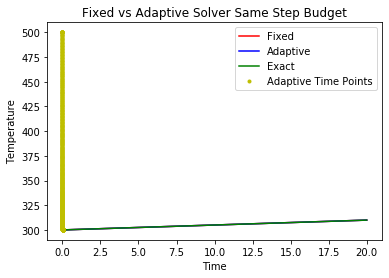

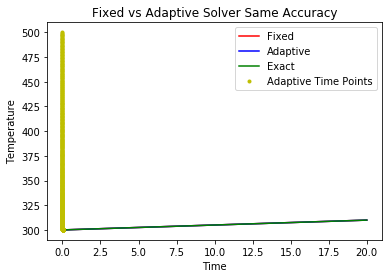

In [282]:
#Plot large starting h
plt.figure()
plt.plot(t_damped,T_damped, 'r-',label="Fixed")
plt.plot(t_vals,T_vals,'b-',label="Adaptive")
plt.plot(t, analytical, 'g-',label="Exact")
plt.plot(t_adapt,y_adapt,'y.',label="Adaptive Time Points")
plt.legend()
plt.title("Fixed vs Adaptive Solver Same Step Budget")
plt.xlabel("Time")
plt.ylabel("Temperature")
plt.show()

#Plot small starting h
plt.title("Fixed vs Adaptive Solver Same Accuracy")
plt.xlabel("Time")
plt.ylabel("Temperature")
plt.plot(t_damped1,T_damped1, 'r-',label="Fixed")
plt.plot(t_vals1,T_vals1,'b-',label="Adaptive")
plt.plot(t, analytical, 'g-',label="Exact")
plt.plot(t_adapt1,y_adapt1,'y.',label="Adaptive Time Points")
plt.legend()
plt.show()

### Section 5: Robustness Testing 

The adaptive solver is clearly able to sustain both accuracy and a reasonable step count with both very large and very small step sizes.